# **Vanilla GAN**

This notebook includes the implementation of VanillaGAN using Tensorflow and the code to train the networks



# **Load the dataset**

In [1]:
!pip install tensorflow_datasets

# Import libraries
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
import keras
from keras import callbacks
from keras import optimizers
from keras.datasets import cifar10
from keras.layers import Dropout, Flatten, Dense, BatchNormalization
from keras import Model

from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

In [2]:
# Get the full dataset (batch_size=-1) in NumPy arrays from the returned tf.Tensor object
cifar10_train = tfds.load(name="cifar10", split=tfds.Split.TRAIN, batch_size=-1 )
cifar10_test = tfds.load(name="cifar10", split=tfds.Split.TEST, batch_size=-1)

# Convert tfds dataset to numpy array records
cifar10_train = tfds.as_numpy(cifar10_train)
cifar10_test = tfds.as_numpy(cifar10_test)

# Seperate feature X and label Y
X_train, y_train = cifar10_train["image"], cifar10_train["label"]
X_test, y_test = cifar10_test["image"], cifar10_test["label"]

# Print shapes of the entire training and test set of CIFAR 10
print("X_train shape: " + str(X_train.shape))
print("X_test shape: " + str(X_test.shape))
print("y_train shape: " + str(y_train.shape))
print("y_test shape: " + str(y_test.shape))

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...:   0%|          | 0/50000 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar10/3.0.2.incompleteCJWTR3/cifar10-train.tfrecord*...:   0%|          …

Generating test examples...:   0%|          | 0/10000 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar10/3.0.2.incompleteCJWTR3/cifar10-test.tfrecord*...:   0%|          |…

Dataset cifar10 downloaded and prepared to /root/tensorflow_datasets/cifar10/3.0.2. Subsequent calls will reuse this data.
X_train shape: (50000, 32, 32, 3)
X_test shape: (10000, 32, 32, 3)
y_train shape: (50000,)
y_test shape: (10000,)


In [3]:
# Get samples  of a certain label
label = 8 # Class '8' is ship.
train_indices = np.where(y_train == label) # Get indices of the label
train_set = X_train[train_indices] # Get train samples of the label
test_indices = np.where(y_test == label) # Get indices of the label
test_set = X_train[test_indices] # Get test samples of the label

# Print shapes of datasets of the selected class
print("train_set shape of the selected class: " + str(train_set.shape))
print("test_set shape of the selected class: " + str(test_set.shape))

# Merge the train_set and test_set because GAN does not require to have train/test split
train_set = np.concatenate((train_set, test_set), axis = 0)

# Print the shape after merged
print("train_set shape after merging: " + str(train_set.shape))

train_set shape of the selected class: (5000, 32, 32, 3)
test_set shape of the selected class: (1000, 32, 32, 3)
train_set shape after merging: (6000, 32, 32, 3)


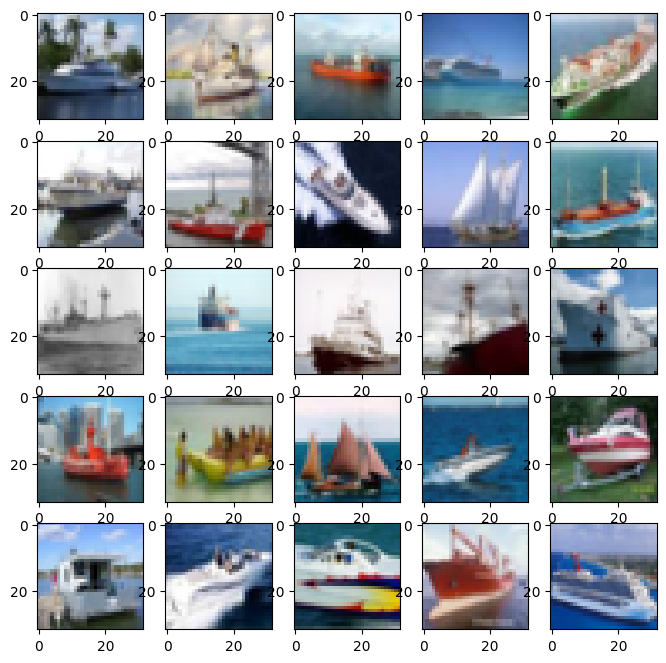

In [4]:
# Visualize some data samples of class '8' (ship)
import matplotlib.pyplot as plt
f, ax = plt.subplots(5, 5, figsize = (8, 8))
ax = ax.ravel()

for i in np.arange(25):
  ax[i].imshow(train_set[i])

# **Process the image**

In [5]:
train_set = train_set.astype('float32')
# Normalize from [0, 255] to [-1, 1] for tanh activation
train_set = (train_set - 127.5) / 127.5

# **First-level requirement: Vanilla GAN**

## Build the Generator

In [6]:
from keras.models import Sequential
from keras.layers import Conv2D, Dense, MaxPooling2D, Flatten, Conv2DTranspose, LeakyReLU, Reshape, Dropout, BatchNormalization, GlobalMaxPooling2D

# Define the structure of Generator
def define_generator(latent_dim):
  # latent_dim: dimension of the random input vector

  model = Sequential() # Initialize a sequential model for Generator

  # Foundation for 4x4 image
  n_nodes = 4*4*256 # Expected vector size for converting to a feature map
  model.add(Dense(input_dim=latent_dim, units=n_nodes)) # FC layer to convert latent vector to a vector of size n_nodes
  model.add(LeakyReLU(alpha=0.2))
  model.add(Reshape((4, 4, 256)))

  # Upsample from 4x4x256 to 8x8x128 using Conv2DTranspose
  model.add(Conv2DTranspose(128, (4,4), strides=(2,2), padding='same'))
  model.add(LeakyReLU(alpha=0.2))

  # Upsample from 8x8x128 to 16x16x128
  model.add(Conv2DTranspose(128, (4,4), strides=(2,2), padding='same'))
  model.add(LeakyReLU(alpha=0.2))

  # Upsample from 16x16x128 to 32x32x128
  model.add(Conv2DTranspose(128, (4,4), strides=(2,2), padding='same'))
  model.add(LeakyReLU(alpha=0.2))

  # Convert from 32x32x128 to 32x32x3 conforming to Discriminator's input
  model.add(Conv2D(3, (3,3), activation='tanh', padding='same'))

  return model # Return the Generator

# Show a sample of Generator structure
generator = define_generator(256)
generator.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 4096)              1052672   
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 4096)              0         
                                                                 
 reshape (Reshape)           (None, 4, 4, 256)         0         
                                                                 
 conv2d_transpose (Conv2DTr  (None, 8, 8, 128)         524416    
 anspose)                                                        
                                                                 
 leaky_re_lu_1 (LeakyReLU)   (None, 8, 8, 128)         0         
                                                                 
 conv2d_transpose_1 (Conv2D  (None, 16, 16, 128)       262272    
 Transpose)                                             

## Build the Discriminator

In [7]:
# Define the structure of Discriminator
def define_discriminator(in_shape=(32,32,3)):
  model = Sequential() # Initialize a sequential model for Discriminator

  # Block 1 conv
  model.add(Conv2D(32, (3,3), strides=(2, 2), padding='same', input_shape=in_shape))
  model.add(LeakyReLU(alpha=0.2))
  model.add(Dropout(0.2))

  # Block 2 conv
  model.add(Conv2D(64, (3,3), strides=(2, 2), padding='same'))
  model.add(LeakyReLU(alpha=0.2))
  model.add(Dropout(0.2))

  # Block 3 conv
  model.add(Conv2D(128, (3,3), strides=(2, 2), padding='same'))
  model.add(LeakyReLU(alpha=0.2))
  model.add(Dropout(0.2))

  # Block 4 conv
  model.add(Conv2D(256, (3,3), strides=(2, 2), padding='same'))
  model.add(LeakyReLU(alpha=0.2))
  model.add(Dropout(0.2))

  # Classifier
  model.add(Flatten())
  model.add(Dropout(0.5))
  model.add(Dense(1, activation='sigmoid'))

  return model # Return the Discriminator

# Show a sample of Discriminator structure
sample_discriminator = define_discriminator()
sample_discriminator.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_1 (Conv2D)           (None, 16, 16, 32)        896       
                                                                 
 leaky_re_lu_4 (LeakyReLU)   (None, 16, 16, 32)        0         
                                                                 
 dropout (Dropout)           (None, 16, 16, 32)        0         
                                                                 
 conv2d_2 (Conv2D)           (None, 8, 8, 64)          18496     
                                                                 
 leaky_re_lu_5 (LeakyReLU)   (None, 8, 8, 64)          0         
                                                                 
 dropout_1 (Dropout)         (None, 8, 8, 64)          0         
                                                                 
 conv2d_3 (Conv2D)           (None, 4, 4, 128)        

## Build the GAN

In [8]:
# Define the GAN network consisting of a Generator and a Discriminator
def define_gan(g_model, d_model):
    # g_model: Generator component
    # d_model: Discriminator component

    model = Sequential() # Initialize a sequential model
    model.add(g_model) # Add the Generator component
    model.add(d_model) # Add the Discriminator component
    return model # Return the GAN

In [9]:
from numpy.random import randn, randint
from numpy import zeros, ones, vstack

# Generate random latent vectors as input for Generator
def generate_latent_points(latent_dim, n_samples):
    # Generate points in the latent space
    x_input = randn(latent_dim * n_samples)
    # Reshape to a batch of inputs for the Generator
    x_input = x_input.reshape(n_samples, latent_dim)
    return x_input

# Select real samples from the real dataset for training purpose
def generate_real_samples(dataset, n_samples):
    # Generate random n_samples sample indices from the dataset
    ix = randint(0, dataset.shape[0], n_samples)
    # Get the images from the list of indices
    X = dataset[ix]
    # Generate labels for the real samples (label=1)
    y = ones((n_samples, 1))
    return X, y # Return the real images and labels.

# Use Generator to generate n_samples fake samples
def generate_fake_samples(g_model, latent_dim, n_samples):
    # Generate random latent vectors as input for Generator
    x_input = generate_latent_points(latent_dim, n_samples)
    # Generate fake data samples by passing the random latent vectors through the Generator
    X = g_model.predict(x_input)
    # Generate labels for the fake samples (label=0)
    y = zeros((n_samples, 1))
    return X, y # Return the fake images and labels.

## Training process

In [10]:
# Train the Generator and the Discriminator
def train(g_model, d_model, gan_model, dataset, latent_dim, n_epochs=201, n_batch=4096):
    bat_per_epo = int(dataset.shape[0] / n_batch) # Number of iterations per epoch
    half_batch = int(n_batch / 2) # A batch to the Discriminator contains real samples (half-batch) and fake samples (half-batch)

    d_loss_values = [] # Array containing Discriminator loss over iterations
    g_loss_values = [] # Array containing Generator loss over iterations

    # Number of epochs
    for i in range(n_epochs):
        # Number of iterations
        for j in range(bat_per_epo):

            # Randomly get half_batch real data samples from the real dataset
            X_real, y_real = generate_real_samples(dataset, half_batch)
            # Generate half_batch fake data samples
            X_fake, y_fake = generate_fake_samples(g_model, latent_dim, half_batch)

            # Create training set for the discriminator: half-batch real and half-batch fake
            X, y = vstack((X_real, X_fake)), vstack((y_real, y_fake))

            # Update discriminator model weights
            d_loss, _ = d_model.train_on_batch(X, y)

            # Generate random latent vectors as input for Generator
            X_gan = generate_latent_points(latent_dim, n_batch)
            # Generate inverted labels for the fake samples to train the Generator
            y_gan = ones((n_batch, 1))
            # Train the Generator
            g_loss = gan_model.train_on_batch(X_gan, y_gan)

            # Training log after every iteration
            print('Epoch %d, Iteration %d/%d, D_loss = %.3f, G_loss = %.3f' % (i+1, j+1, bat_per_epo, d_loss, g_loss))

            # Add loss values to historical arrays
            d_loss_values.append(d_loss)
            g_loss_values.append(g_loss)

        # Plot the generated images every certain number of epochs
        if (i+1) % 10 == 0:
            X_fake, _ = generate_fake_samples(g_model, latent_dim, 100) # Generate 100 fake data samples using the Generator. Pixel values are in [0,1]
            save_plot(X_fake, i, n=10) # Plot a grid of 10x10 fake samples and save to file at epoch i

    return d_loss_values, g_loss_values # Return the loss arrays of Generator and Discriminator

In [11]:
from matplotlib import pyplot

# Create and save a plot of generated images
def save_plot(samples, epoch, n=10):
    # Define a plot of (n rows, n columns)
    for i in range(n * n):
        # (1+i) is the index position on a grid with nrows rows and ncols columns. Index starts at 1 in the upper left corner and increases to the right.
        pyplot.subplot(n, n, 1+i)
        pyplot.axis('off') # Disable axis
        pyplot.imshow(samples[i, :, :, 0], cmap='gray_r') # Plot the sample i with reversed gay color map
    filename = 'Plot_epoch_%03d.png' % (epoch+1)
    pyplot.savefig(filename) # Save plot to file
    pyplot.close() # Close the plot

## Main code

In [12]:
# Import optimization library
from keras.optimizers.legacy import Adam, SGD

# Size of the latent space
latent_dim = 256
epochs = 500
batch_size = 32

# Initialize an optimizer. Pick one.
opt = Adam(learning_rate=0.0002, beta_1=0.5) # Adam optimizer with customized values (for the best result)
# opt = Adam() # Adam optimizer with default values
# opt = SGD() # SGD optimizer with default values

# Create the Discriminator
d_model = define_discriminator()
d_model.trainable = True
d_model.compile(loss='binary_crossentropy', optimizer=opt, metrics=['accuracy'])

# Create the Generator
g_model = define_generator(latent_dim)

# Create the GAN
d_model.trainable = False
gan_model = define_gan(g_model, d_model)
gan_model.compile(loss='binary_crossentropy', optimizer=opt)

# Train the GAN
d_losses, g_losses = train(g_model, d_model, gan_model, train_set, latent_dim, epochs, batch_size)

Kết quả truyền trực tuyến bị cắt bớt đến 5000 dòng cuối.
Epoch 487, Iteration 120/187, D_loss = 0.655, G_loss = 0.994
1/1 [==============================] - 0s 18ms/step
Epoch 487, Iteration 121/187, D_loss = 0.695, G_loss = 0.925
1/1 [==============================] - 0s 18ms/step
Epoch 487, Iteration 122/187, D_loss = 0.599, G_loss = 0.811
1/1 [==============================] - 0s 19ms/step
Epoch 487, Iteration 123/187, D_loss = 0.670, G_loss = 0.811
1/1 [==============================] - 0s 18ms/step
Epoch 487, Iteration 124/187, D_loss = 0.674, G_loss = 0.827
1/1 [==============================] - 0s 20ms/step
Epoch 487, Iteration 125/187, D_loss = 0.637, G_loss = 0.801
1/1 [==============================] - 0s 19ms/step
Epoch 487, Iteration 126/187, D_loss = 0.674, G_loss = 0.750
1/1 [==============================] - 0s 18ms/step
Epoch 487, Iteration 127/187, D_loss = 0.707, G_loss = 0.782
1/1 [==============================] - 0s 19ms/step
Epoch 487, Iteration 128/187, D_loss = 

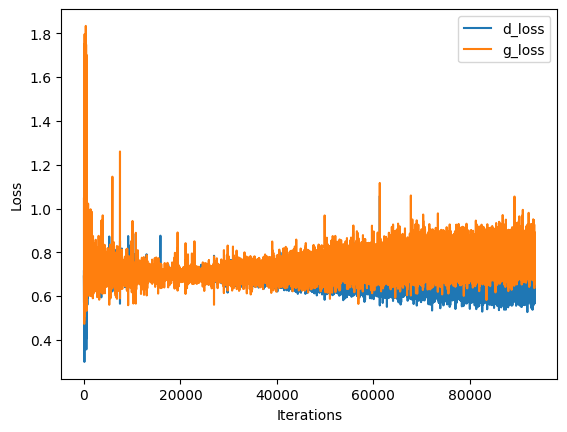

In [13]:
### Plot the training loss of the Generator and the Discriminator over iterations

# Initialize values of x-axis (iterations)
dx = np.linspace(0, len(d_losses), len(d_losses))
gx = np.linspace(0,len(g_losses), len(d_losses))

# Plot the training loss of G and D
plt.plot(dx, d_losses)
plt.plot(gx, g_losses)
plt.ylabel('Loss')
plt.xlabel('Iterations')
plt.legend(['d_loss', 'g_loss'], loc='upper right')
plt.show()

## Save and load the models

In [14]:
# Save the Discriminator, Generator and GAN model
d_model.save('d_model.sav')
g_model.save('g_model.sav')
gan_model.save('gan_model.sav')

4/4 [==============================] - 0s 7ms/step


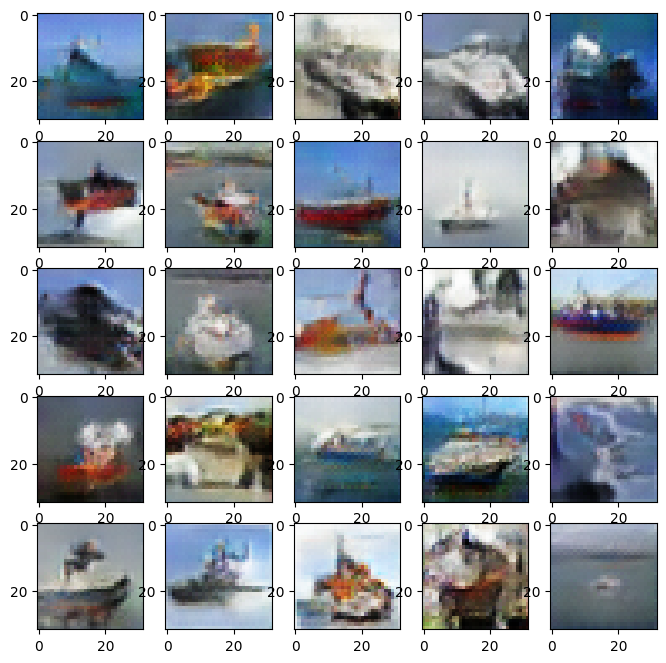

In [17]:
# Load the Generator from saved model
g_model = keras.models.load_model("g_model.sav")

# Generate 100 fake images by passing 100-dimensional random vectors through the Generator.
X_fake, _ = generate_fake_samples(g_model, 256, 100)

# Unnormalize to visualize image
X_fake = ((X_fake * 127.5) + 127.5).astype(np.uint8)

# Visualize the generated images
f, ax = plt.subplots(5, 5, figsize = (8, 8))
ax = ax.ravel()

for i in np.arange(25):
  ax[i].imshow(X_fake[i])

In [16]:
# Compress output folders for downloading

!zip -r /content/d_model.zip /content/d_model.sav
!zip -r /content/g_model.zip /content/g_model.sav
!zip -r /content/gan_model.zip /content/gan_model.sav

  adding: content/d_model.sav/ (stored 0%)
  adding: content/d_model.sav/keras_metadata.pb (deflated 92%)
  adding: content/d_model.sav/assets/ (stored 0%)
  adding: content/d_model.sav/fingerprint.pb (stored 0%)
  adding: content/d_model.sav/variables/ (stored 0%)
  adding: content/d_model.sav/variables/variables.data-00000-of-00001 (deflated 9%)
  adding: content/d_model.sav/variables/variables.index (deflated 66%)
  adding: content/d_model.sav/saved_model.pb (deflated 89%)
  adding: content/g_model.sav/ (stored 0%)
  adding: content/g_model.sav/keras_metadata.pb (deflated 92%)
  adding: content/g_model.sav/assets/ (stored 0%)
  adding: content/g_model.sav/fingerprint.pb (stored 0%)
  adding: content/g_model.sav/variables/ (stored 0%)
  adding: content/g_model.sav/variables/variables.data-00000-of-00001 (deflated 7%)
  adding: content/g_model.sav/variables/variables.index (deflated 56%)
  adding: content/g_model.sav/saved_model.pb (deflated 89%)
  adding: content/gan_model.sav/ (stor